In [1]:
import json
import numpy as np
from collections import defaultdict

# Load inference results
with open('inference_tests_files/yolo_single_classification_batch_11908.json') as f:
    yolo_data = json.load(f)
with open('inference_tests_files/llm_single_classification_batch_11908.json') as f:
    vlm_data = json.load(f)

print(f'YOLO total predictions: {len(yolo_data["detailed_predictions"])}')
print(f'VLM total predictions:  {len(vlm_data["detailed_predictions"])}')

YOLO total predictions: 11908
VLM total predictions:  11908


In [2]:
# ── Define the test set ───────────────────────────────────────────────────────
# Classes collected separately (never used for YOLO training).
# Their images sit in the Training/ folder but should be treated as validation.
COLLECTED_CLASSES = {'Boat', 'Stairs', 'Taxi', 'Tractor'}

ALL_CLASSES = ['Bicycle', 'Boat', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
               'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm', 'Stairs',
               'Taxi', 'Tractor', 'Traffic Light']

# YOLO model supports 13 classes (not Boat, Taxi, Tractor)
YOLO_SUPPORTED = {'Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
                  'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm', 'Stairs',
                  'Traffic Light'}

def is_test_image(path):
    """Image belongs to the test set if:
       - It's from the Validation/ folder (any class), OR
       - It's from Training/ for a collected class (Boat, Stairs, Taxi, Tractor)
    """
    if '/Validation/' in path:
        return True
    for cls in COLLECTED_CLASSES:
        if f'/Training/{cls}/' in path:
            return True
    return False

# Filter BOTH models to the same 893-image test set
yolo_test = [p for p in yolo_data['detailed_predictions'] if is_test_image(p['image_path'])]
vlm_test  = [p for p in vlm_data['detailed_predictions'] if is_test_image(p['image_path'])]

print(f'YOLO test set: {len(yolo_test)} images')
print(f'VLM test set:  {len(vlm_test)} images')
assert len(yolo_test) == len(vlm_test), 'Both models must have the same test set size!'

YOLO test set: 893 images
VLM test set:  893 images


In [3]:
# ── Per-class sample counts in the YOLO test set ─────────────────────────────
counts = defaultdict(int)
for p in yolo_test:
    counts[p['ground_truth']] += 1

print(f'{"Class":<15s} {"N (test)":>8s}  Source')
print('-' * 50)
for cls in ALL_CLASSES:
    n = counts.get(cls, 0)
    if cls in COLLECTED_CLASSES:
        src = 'Collected (treated as validation)'
    else:
        src = 'Validation folder'
    supported = '' if cls in YOLO_SUPPORTED else ' [unsupported by YOLO]'
    print(f'{cls:<15s} {n:>8d}  {src}{supported}')
print(f'{"TOTAL":<15s} {sum(counts.values()):>8d}')

Class           N (test)  Source
--------------------------------------------------
Bicycle               74  Validation folder
Boat                  11  Collected (treated as validation) [unsupported by YOLO]
Bridge                74  Validation folder
Bus                   74  Validation folder
Car                   74  Validation folder
Chimney               17  Validation folder
Crosswalk             74  Validation folder
Hydrant               74  Validation folder
Motorcycle            74  Validation folder
Mountain               2  Validation folder
Other                 74  Validation folder
Palm                  74  Validation folder
Stairs                75  Collected (treated as validation)
Taxi                  28  Collected (treated as validation) [unsupported by YOLO]
Tractor               20  Collected (treated as validation) [unsupported by YOLO]
Traffic Light         74  Validation folder
TOTAL                893


In [4]:
# ── Metric computation helper ────────────────────────────────────────────────
def compute_metrics(predictions, label='Model'):
    """Compute per-class Precision, Recall, F1 and overall/macro accuracy."""
    tp = defaultdict(int)
    fp = defaultdict(int)
    fn = defaultdict(int)
    total = defaultdict(int)

    for p in predictions:
        gt = p['ground_truth']
        pred = p['predicted_class']
        total[gt] += 1
        if gt == pred:
            tp[gt] += 1
        else:
            fn[gt] += 1
            fp[pred] += 1

    per_class = {}
    for cls in ALL_CLASSES:
        n = total.get(cls, 0)
        if n == 0:
            per_class[cls] = {'n': 0, 'prec': None, 'rec': None, 'f1': None}
            continue
        prec = tp[cls] / (tp[cls] + fp[cls]) * 100 if (tp[cls] + fp[cls]) > 0 else 0.0
        rec  = tp[cls] / (tp[cls] + fn[cls]) * 100 if (tp[cls] + fn[cls]) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[cls] = {'n': n, 'prec': prec, 'rec': rec, 'f1': f1}

    total_correct = sum(tp.values())
    total_images  = sum(total.values())
    overall_acc   = total_correct / total_images * 100

    class_accs = [tp[c] / total[c] * 100 for c in ALL_CLASSES if total.get(c, 0) > 0]
    macro_acc  = np.mean(class_accs)

    recs  = [pc['rec']  for pc in per_class.values() if pc['rec'] is not None]
    precs = [pc['prec'] for pc in per_class.values() if pc['prec'] is not None]
    f1s   = [pc['f1']   for pc in per_class.values() if pc['f1'] is not None]

    return {
        'per_class': per_class,
        'overall_acc': overall_acc,
        'macro_acc': macro_acc,
        'macro_prec': np.mean(precs),
        'macro_rec': np.mean(recs),
        'macro_f1': np.mean(f1s),
        'total_images': total_images,
        'total_correct': total_correct,
    }

In [5]:
# ── YOLO: metrics (893-image test set) ─────────────────────────────
yolo_m = compute_metrics(yolo_test, 'YOLO')

print('YOLO — Test Set (893 images)')
print('=' * 55)
print(f'{"Class":<15s} {"N":>5s} {"Prec":>8s} {"Rec":>8s} {"F1":>8s}')
print('-' * 55)
for cls in ALL_CLASSES:
    pc = yolo_m['per_class'][cls]
    if pc['n'] == 0:
        print(f'{cls:<15s} {0:>5d} {"---":>8s} {"---":>8s} {"---":>8s}')
    else:
        print(f'{cls:<15s} {pc["n"]:>5d} {pc["prec"]:>7.1f}% {pc["rec"]:>7.1f}% {pc["f1"]:>7.1f}%')
print('-' * 55)
print(f'{"Macro Avg":<15s} {"":>5s} {yolo_m["macro_prec"]:>7.1f}% {yolo_m["macro_rec"]:>7.1f}% {yolo_m["macro_f1"]:>7.1f}%')
print(f'\nOverall Accuracy: {yolo_m["total_correct"]}/{yolo_m["total_images"]} = {yolo_m["overall_acc"]:.1f}%')
print(f'Macro Accuracy:   {yolo_m["macro_acc"]:.1f}%')

YOLO — Test Set (893 images)
Class               N     Prec      Rec       F1
-------------------------------------------------------
Bicycle            74    81.5%    89.2%    85.2%
Boat               11     0.0%     0.0%     0.0%
Bridge             74    82.7%    83.8%    83.2%
Bus                74    84.7%    97.3%    90.6%
Car                74    41.0%    77.0%    53.5%
Chimney            17    84.6%    64.7%    73.3%
Crosswalk          74    85.9%    90.5%    88.2%
Hydrant            74    96.1%   100.0%    98.0%
Motorcycle         74    89.5%    68.9%    77.9%
Mountain            2     0.0%     0.0%     0.0%
Other              74    45.0%    66.2%    53.6%
Palm               74    95.1%    78.4%    85.9%
Stairs             75    91.5%    57.3%    70.5%
Taxi               28     0.0%     0.0%     0.0%
Tractor            20     0.0%     0.0%     0.0%
Traffic Light      74    90.1%    86.5%    88.3%
-------------------------------------------------------
Macro Avg                6

In [6]:
# ── VLM: Same 893-image test set ─────────────────────────────────────────────
vlm_m = compute_metrics(vlm_test, 'VLM')

print(f'VLM — Test Set ({vlm_m["total_images"]} images)')
print('=' * 55)
print(f'{"Class":<15s} {"N":>5s} {"Prec":>8s} {"Rec":>8s} {"F1":>8s}')
print('-' * 55)
for cls in ALL_CLASSES:
    pc = vlm_m['per_class'][cls]
    if pc['n'] == 0:
        print(f'{cls:<15s} {0:>5d} {"---":>8s} {"---":>8s} {"---":>8s}')
    else:
        print(f'{cls:<15s} {pc["n"]:>5d} {pc["prec"]:>7.1f}% {pc["rec"]:>7.1f}% {pc["f1"]:>7.1f}%')
print('-' * 55)
print(f'{"Macro Avg":<15s} {"":>5s} {vlm_m["macro_prec"]:>7.1f}% {vlm_m["macro_rec"]:>7.1f}% {vlm_m["macro_f1"]:>7.1f}%')
print(f'\nOverall Accuracy: {vlm_m["total_correct"]}/{vlm_m["total_images"]} = {vlm_m["overall_acc"]:.1f}%')
print(f'Macro Accuracy:   {vlm_m["macro_acc"]:.1f}%')

VLM — Test Set (893 images)
Class               N     Prec      Rec       F1
-------------------------------------------------------
Bicycle            74    97.2%    94.6%    95.9%
Boat               11    91.7%   100.0%    95.7%
Bridge             74    59.4%    85.1%    70.0%
Bus                74    94.8%    98.6%    96.7%
Car                74    47.7%    82.4%    60.4%
Chimney            17    78.9%    88.2%    83.3%
Crosswalk          74    91.2%    41.9%    57.4%
Hydrant            74    94.9%   100.0%    97.4%
Motorcycle         74    94.5%    93.2%    93.9%
Mountain            2   100.0%    50.0%    66.7%
Other              74    84.2%    21.6%    34.4%
Palm               74    96.3%    70.3%    81.2%
Stairs             75    91.0%    94.7%    92.8%
Taxi               28    95.8%    82.1%    88.5%
Tractor            20   100.0%   100.0%   100.0%
Traffic Light      74    70.4%    93.2%    80.2%
-------------------------------------------------------
Macro Avg                86

In [7]:
# ── 12-class metrics (excludes all collected classes) ─────────────────────────
VAL_CLASSES = [c for c in ALL_CLASSES if c not in COLLECTED_CLASSES]

yt12 = [p for p in yolo_test if p['ground_truth'] in VAL_CLASSES]
vt12 = [p for p in vlm_test if p['ground_truth'] in VAL_CLASSES]

# Per-class recall on 12 classes — used by the ORACLE router only.
# This table is computed on the test set itself, so the router that consults
# it is not deployable; it serves as an upper bound for any class-conditional
# routing scheme.
def pcr_subset(preds, classes):
    correct = defaultdict(int); total = defaultdict(int)
    for p in preds:
        if p['ground_truth'] not in classes: continue
        total[p['ground_truth']] += 1
        if p['correct']: correct[p['ground_truth']] += 1
    return {c: correct[c]/total[c] if total[c]>0 else 0 for c in classes}

yr12 = pcr_subset(yolo_test, VAL_CLASSES)
vr12 = pcr_subset(vlm_test, VAL_CLASSES)

# Oracle router: for each sample, use the ground-truth class to look up which
# model has higher per-class recall, then take that model's prediction.
# Two reasons this is an oracle, not a deployable system:
#   (1) It uses the ground-truth class `gt` at routing time.
#   (2) The recall table that drives routing was fit on this same test set.
# Reported as a ceiling for what any class-conditional router could achieve.
vlm_lookup = {p['image_path']: p for p in vlm_test}
oc12 = defaultdict(int); ot12 = defaultdict(int)
for p in yt12:
    gt = p['ground_truth']
    ot12[gt] += 1
    if yr12[gt] >= vr12[gt]:
        ok = p['correct']
    else:
        ok = vlm_lookup[p['image_path']]['correct']
    if ok: oc12[gt] += 1

y12_overall = sum(1 for p in yt12 if p['correct']) / len(yt12)
v12_overall = sum(1 for p in vt12 if p['correct']) / len(vt12)
o12_overall = sum(oc12.values()) / len(yt12)

y12_macro = np.mean([yr12[c]*100 for c in VAL_CLASSES]) / 100
v12_macro = np.mean([vr12[c]*100 for c in VAL_CLASSES]) / 100
o12_macro = np.mean([oc12[c]/ot12[c] for c in VAL_CLASSES if ot12[c]>0])

print(f'12-class metrics (N={len(yt12)}, excludes Boat/Stairs/Taxi/Tractor):')
print(f'{"Metric":<20s} {"YOLO":>10s} {"VLM":>10s} {"Oracle":>10s}')
print('-' * 55)
print(f'{"Overall Accuracy":<20s} {y12_overall:>10.4f} {v12_overall:>10.4f} {o12_overall:>10.4f}')
print(f'{"Macro Accuracy":<20s} {y12_macro:>10.4f} {v12_macro:>10.4f} {o12_macro:>10.4f}')
print()
print('Oracle column: upper bound for any class-conditional router.')
print('  - Uses ground-truth class at routing time (not available in deployment).')
print('  - Per-class recall table fit on this same test set.')
print('  Reported as a ceiling, not a usable system.')
print()
print(f'Oracle vs YOLO (12 classes):')
print(f'  Overall: +{(o12_overall - y12_overall)*100:.1f}pp')
print(f'  Macro:   +{(o12_macro - y12_macro)*100:.1f}pp')

12-class metrics (N=759, excludes Boat/Stairs/Taxi/Tractor):
Metric                     YOLO        VLM     Oracle
-------------------------------------------------------
Overall Accuracy         0.8314     0.7826     0.8814
Macro Accuracy           0.7521     0.7661     0.8506

Oracle column: upper bound for any class-conditional router.
  - Uses ground-truth class at routing time (not available in deployment).
  - Per-class recall table fit on this same test set.
  Reported as a ceiling, not a usable system.

Oracle vs YOLO (12 classes):
  Overall: +5.0pp
  Macro:   +9.8pp


In [8]:
# ── Table 3: Per-class Precision, Recall, F1 ─────────────────────
# Both YOLO and VLM on the same 893-image test set

print('TABLE 3: Per-class Precision, Recall, and F1 scores')
print(f'Both models on same {yolo_m["total_images"]}-image test set')
print('=' * 85)
print(f'{"Class":<15s} | {"":^27s} YOLO {"":^27s} | {"":^27s} VLM {"":^28s}')
print(f'{"":<15s} | {"Prec":>8s} {"Rec":>8s} {"F1":>8s} | {"Prec":>8s} {"Rec":>8s} {"F1":>8s}')
print('-' * 70)
for cls in ALL_CLASSES:
    ypc = yolo_m['per_class'][cls]
    vpc = vlm_m['per_class'][cls]
    unsupported = ' +' if cls in {'Boat', 'Taxi', 'Tractor'} else ''
    
    if ypc['n'] == 0:
        y_str = f'{"---":>8s} {"---":>8s} {"---":>8s}'
    else:
        y_str = f'{ypc["prec"]:>7.1f}% {ypc["rec"]:>7.1f}% {ypc["f1"]:>7.1f}%'
    
    if vpc['n'] == 0:
        v_str = f'{"---":>8s} {"---":>8s} {"---":>8s}'
    else:
        v_str = f'{vpc["prec"]:>7.1f}% {vpc["rec"]:>7.1f}% {vpc["f1"]:>7.1f}%'
    
    print(f'{cls + unsupported:<15s} | {y_str} | {v_str}')

print('-' * 70)
print(f'{"Macro Avg":<15s} | {yolo_m["macro_prec"]:>7.1f}% {yolo_m["macro_rec"]:>7.1f}% {yolo_m["macro_f1"]:>7.1f}% | {vlm_m["macro_prec"]:>7.1f}% {vlm_m["macro_rec"]:>7.1f}% {vlm_m["macro_f1"]:>7.1f}%')
print(f'\n+ Unsupported by YOLO Classification Model')

TABLE 3: Per-class Precision, Recall, and F1 scores
Both models on same 893-image test set
Class           |                             YOLO                             |                             VLM                             
                |     Prec      Rec       F1 |     Prec      Rec       F1
----------------------------------------------------------------------
Bicycle         |    81.5%    89.2%    85.2% |    97.2%    94.6%    95.9%
Boat +          |     0.0%     0.0%     0.0% |    91.7%   100.0%    95.7%
Bridge          |    82.7%    83.8%    83.2% |    59.4%    85.1%    70.0%
Bus             |    84.7%    97.3%    90.6% |    94.8%    98.6%    96.7%
Car             |    41.0%    77.0%    53.5% |    47.7%    82.4%    60.4%
Chimney         |    84.6%    64.7%    73.3% |    78.9%    88.2%    83.3%
Crosswalk       |    85.9%    90.5%    88.2% |    91.2%    41.9%    57.4%
Hydrant         |    96.1%   100.0%    98.0% |    94.9%   100.0%    97.4%
Motorcycle      |    89.5%    

Saved: figs/yolo_confusion_matrix.png


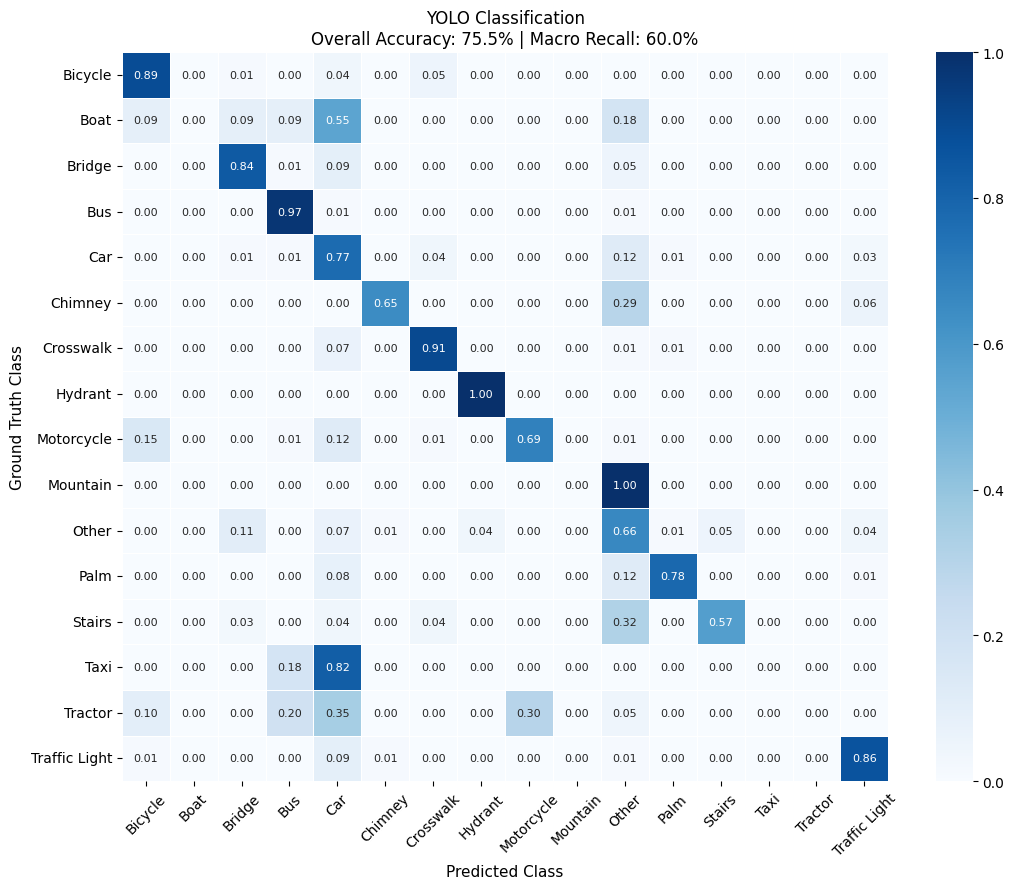

Saved: figs/vlm_confusion_matrix.png


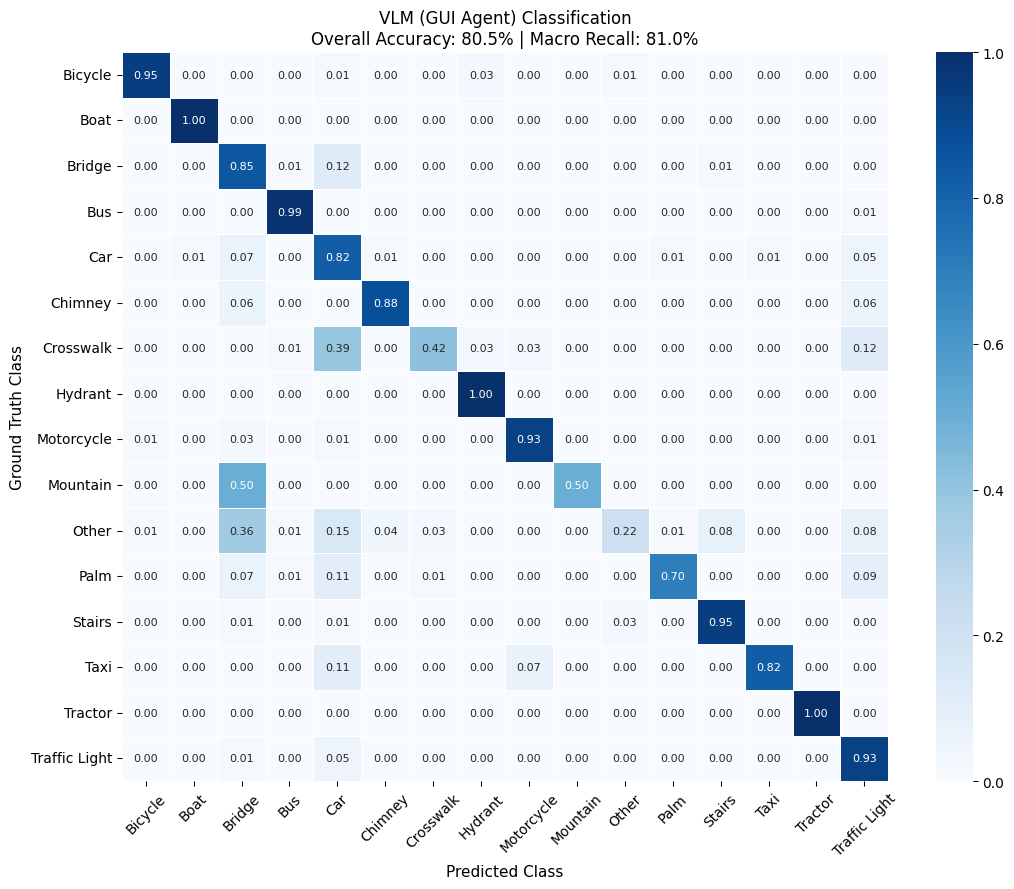

In [9]:
# ── Confusion Matrices: YOLO and VLM (893-image test set) ────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

class_to_idx = {c: i for i, c in enumerate(ALL_CLASSES)}
N_CLASSES = len(ALL_CLASSES)

def build_confusion_matrix(predictions):
    """Build N_CLASSES x N_CLASSES confusion matrix from predictions."""
    conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
    for p in predictions:
        gt = p['ground_truth']
        pred = p['predicted_class']
        if gt in class_to_idx and pred in class_to_idx:
            conf[class_to_idx[gt], class_to_idx[pred]] += 1
    return conf

def plot_confusion(conf, title, save_path):
    """Plot and save a single normalized confusion matrix."""
    fig, ax = plt.subplots(figsize=(11, 9))

    conf_norm = conf.astype(float)
    for i in range(N_CLASSES):
        row_sum = conf_norm[i].sum()
        if row_sum > 0:
            conf_norm[i] /= row_sum

    macro_recall = np.mean([conf_norm[i, i] for i in range(N_CLASSES)])
    overall_acc = np.trace(conf) / conf.sum()

    sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=ALL_CLASSES, yticklabels=ALL_CLASSES,
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={'size': 8})
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('Ground Truth Class', fontsize=11)
    ax.set_title(f'{title}\nOverall Accuracy: {overall_acc:.1%} | Macro Recall: {macro_recall:.1%}',
                 fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

yolo_conf = build_confusion_matrix(yolo_test)
vlm_conf  = build_confusion_matrix(vlm_test)

plot_confusion(yolo_conf, 'YOLO Classification', 'figs/yolo_confusion_matrix.png')
plot_confusion(vlm_conf, 'VLM (GUI Agent) Classification', 'figs/vlm_confusion_matrix.png')